What this notebook covers:
- markdown cells render normally
- Python code executes through the shared `python3` kernel
- PyTorch imports correctly
- autograd works
- a tiny training loop runs
- matplotlib output can be shown and saved back into the notebook

## 1. Environment check

In [1]:
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

print('python executable:', sys.executable.replace(str(Path.home()), '~', 1))
print('python version   :', platform.python_version())
print('torch version    :', torch.__version__)
print('cuda available   :', torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('selected device  :', device)


python executable: ~/dotfiles/nvim/.venv/bin/python3
python version   : 3.11.15
torch version    : 2.11.0+cu130
cuda available   : True
selected device  : cuda


## 2. Tensor basics

In [2]:
torch.manual_seed(7)

x = torch.tensor([[1.0, 2.0], [3.0, 4.0]], device=device)
w = torch.tensor([[2.0], [-1.0]], device=device)
y = x @ w

print('x =')
print(x)
print('\nw =')
print(w)
print('\ny = x @ w =')
print(y)


x =


tensor([[1., 2.],
        [3., 4.]], device='cuda:0')

w =
tensor([[ 2.],
        [-1.]], device='cuda:0')

y = x @ w =
tensor([[0.],
        [2.]], device='cuda:0')


## 3. Autograd

In [3]:
x = torch.tensor(2.0, requires_grad=True, device=device)
f = x**2 + 3 * x
f.backward()

print('f(x)      =', f.item())
print('df/dx @ 2 =', x.grad.item())


f(x)      = 10.0
df/dx @ 2 = 7.0


## 4. Tiny linear regression

In [4]:
torch.manual_seed(42)

inputs = torch.linspace(-1, 1, 100, device=device).unsqueeze(1)
targets = 3 * inputs + 1 + 0.15 * torch.randn_like(inputs)

model = torch.nn.Linear(1, 1).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = torch.nn.MSELoss()

loss_history = []

for step in range(200):
    predictions = model(inputs)
    loss = loss_fn(predictions, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

weight = model.weight.item()
bias = model.bias.item()

print(f'learned weight: {weight:.3f}')
print(f'learned bias  : {bias:.3f}')
print(f'final loss    : {loss_history[-1]:.6f}')


learned weight: 2.996
learned bias  : 0.997
final loss    : 0.019225


## 5. Plot training loss

hello


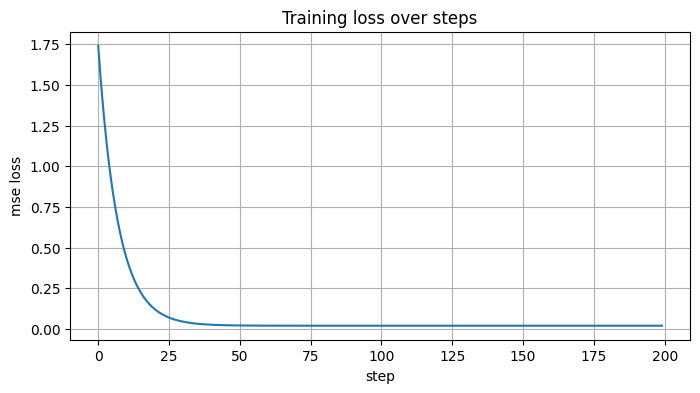

In [5]:
print('hello')
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title('Training loss over steps')
plt.xlabel('step')
plt.ylabel('mse loss')
plt.grid(True)
plt.show()


## 6. Optional next step
If everything works, duplicate this notebook into `01_tensors.ipynb`, `02_autograd.ipynb`, `03_linear_regression.ipynb`, and later `04_mlp.ipynb` as you go through your course.